# CMIP6-style SST patching: "what-if" scenario forecasts

Because `aifs-modal` decouples ingestion from inference, any IC source that follows the Brightband zarr schema can be fed to the model. This notebook demonstrates that flexibility by constructing a *modified* set of initial conditions by (i) patching sea-surface temperatures (SSTs) with a CMIP6 end-of-century warming anomaly, (ii) writing them to a new ArrayLake repository, and (iii) running a forecast from it.

The recipe:

1. Run a baseline forecast from the Brightband IFS dataset on ArrayLake.
2. Compute a monthly SST anomaly from the [Pangeo CMIP6 cloud archive](https://pangeo-data.github.io/pangeo-cmip6-cloud/) (SSP5-8.5, 2050–2069 minus historical 1995–2014) and regrid it to the Brightband 0.25° lat/lon grid.
3. Open the Brightband source, apply the CMIP6 anomaly to skin temperature (`skt`) and 2 m temperature (`2t`) over ocean (where `lsm < 0.5`), and write the patched ICs to an ArrayLake repository.
4. Run a forecast from the patched ICs and compare against the baseline.

```{note}
This notebook is primarily a **library demo**: it illustrates how to write custom ICs into an ArrayLake repository and run `aifs-modal` from them. The physical interpretation of a single-date, 4-day forecast response to a large SST anomaly is very limited.
```

In [ ]:
import datetime as dt
import os

import arraylake
import gcsfs
import icechunk
import numpy as np
import pandas as pd
import scipy.interpolate
import xarray as xr

import plot_utils  # supplied alongside the other docs notebooks
from aifs_modal import app, run_forecast

In [ ]:
_today_00z = dt.datetime.now(dt.UTC).replace(hour=0, minute=0, second=0, microsecond=0)
start_date = _today_00z - dt.timedelta(
    days=2
)  # safely within the Brightband ~15-day window
lead_time = 96  # hours

storage_bucket = "aifs-modal-unibe"
ifs_source_repo = "martibosch/ecmwf-ifs-hres-ics-open"  # Brightband ECMWF IFS dataset
patched_ics_repo = (
    "martibosch/aifs-modal-sst-2t-patched"  # ArrayLake repo for patched ICs
)
baseline_outputs_prefix = "aifs-outputs-ifs-baseline"
patched_outputs_prefix = "aifs-outputs-ifs-warm-2t-skt-patch"

# CMIP6 source for the SST anomaly (Pangeo cloud archive, anonymous GCS)
# Change source_id / institution to use a different model; check available
# combinations at https://pangeo-data.github.io/pangeo-cmip6-cloud/
cmip6_source_id = "IPSL-CM6A-LR"
cmip6_institution = "IPSL"
cmip6_member_id = "r1i1p1f1"
cmip6_hist_period = slice("1995", "2014")
cmip6_ssp_period = slice("2050", "2069")

print(f"start_date: {start_date.isoformat()}")

start_date: 2026-05-12T00:00:00+00:00


## 1. Run the baseline forecast

In [ ]:
with app.run():
    run_forecast.remote(
        start_date,
        storage_bucket,
        ic_source="ifs-arraylake",
        ic_source_repo=ifs_source_repo,
        lead_time=lead_time,
        outputs_prefix=baseline_outputs_prefix,
    )

## 2. Compute CMIP6 SST anomaly

We load monthly mean sea-surface temperature (`tos`) from the Pangeo CMIP6 zarr archive on Google Cloud Storage and compute the SSP5-8.5 end-of-century anomaly relative to the historical baseline. The store URL is looked up from the Pangeo catalog CSV, which avoids hard-coding the `gr` vs `gn` grid-label that varies by model and variable. The anomaly is then regridded to the Brightband 0.25° lat/lon grid using `scipy.interpolate.griddata`, which handles both regular and curvilinear (e.g. IPSL ORCA1 tripolar) source grids.

```{note}
This step runs locally and requires `gcsfs`, `pandas`, and `scipy` (`pip install gcsfs pandas scipy`). Access is anonymous — no GCS credentials needed. The default model is IPSL-CM6A-LR; to use another, update `cmip6_source_id`, `cmip6_institution`, and `cmip6_member_id` in the setup cell.
```

In [ ]:
fs = gcsfs.GCSFileSystem(token="anon", access="read_only")

print("Looking up CMIP6 catalog…")
catalog = pd.read_csv(
    "https://cmip6.storage.googleapis.com/pangeo-cmip6.csv",
    dtype=str,
)


def _cmip6_zstore(experiment_id, table_id="Omon", variable_id="tos"):
    activity = (  # noqa: F841
        "CMIP" if experiment_id == "historical" else "ScenarioMIP"
    )
    hits = catalog.query(
        "activity_id == @activity"
        " and institution_id == @cmip6_institution"
        " and source_id == @cmip6_source_id"
        " and experiment_id == @experiment_id"
        " and member_id == @cmip6_member_id"
        " and table_id == @table_id"
        " and variable_id == @variable_id"
    )
    if hits.empty:
        raise FileNotFoundError(
            f"No {variable_id}/{table_id} entry for {cmip6_source_id} {experiment_id} "
            "in Pangeo catalog. Browse https://pangeo-data.github.io/pangeo-cmip6-cloud/"
        )
    zstore = hits.sort_values("zstore").iloc[-1]["zstore"]
    print(f"  {experiment_id}: {zstore}")
    return zstore


print("Loading CMIP6 SST…")
tos_hist = (
    xr.open_zarr(
        fs.get_mapper(_cmip6_zstore("historical")), consolidated=True, chunks={}
    )["tos"]
    .sel(time=cmip6_hist_period)
    .groupby("time.month")
    .mean()
)
tos_ssp585 = (
    xr.open_zarr(fs.get_mapper(_cmip6_zstore("ssp585")), consolidated=True, chunks={})[
        "tos"
    ]
    .sel(time=cmip6_ssp_period)
    .groupby("time.month")
    .mean()
)
sst_anomaly = (tos_ssp585 - tos_hist).compute()  # (month=12, ...), NaN over land

# Regrid to regular 0.25° lat/lon grid — griddata handles both regular (1D) and
# curvilinear (2D, e.g. IPSL ORCA1 tripolar) source coordinate arrays.
target_lat = np.arange(90, -90.25, -0.25)  # (721,)
target_lon = np.arange(0, 360, 0.25)  # (1440,)
target_lon_g, target_lat_g = np.meshgrid(target_lon, target_lat)

month_field = sst_anomaly.sel(month=start_date.month)

# Resolve lat/lon coordinate arrays — try CF standard names first
lat_name = next(
    (c for c in ["latitude", "lat", "nav_lat"] if c in month_field.coords), None
)
lon_name = next(
    (c for c in ["longitude", "lon", "nav_lon"] if c in month_field.coords), None
)
src_lat = month_field.coords[lat_name].values  # (y,) or (y, x)
src_lon = month_field.coords[lon_name].values  # (x,) or (y, x)
if src_lat.ndim == 1:
    src_lon, src_lat = np.meshgrid(src_lon, src_lat)

src_vals = month_field.values.ravel()
src_lon_r = src_lon.ravel()
src_lat_r = src_lat.ravel()

# Normalize lon to [0, 360] so source and target share the same range
src_lon_r = np.where(src_lon_r < 0, src_lon_r + 360, src_lon_r)

valid = ~np.isnan(src_vals)
month_anomaly_025 = scipy.interpolate.griddata(
    np.column_stack([src_lon_r[valid], src_lat_r[valid]]),
    src_vals[valid],
    (target_lon_g, target_lat_g),
    method="linear",
    fill_value=0.0,
).astype("f4")  # (721, 1440); 0 where interpolation hull has no coverage

print(
    f"Month {start_date.month} SST anomaly "
    f"({cmip6_source_id} SSP5-8.5 {cmip6_ssp_period.start}–{cmip6_ssp_period.stop} "
    f"− hist {cmip6_hist_period.start}–{cmip6_hist_period.stop}): "
    f"mean={month_anomaly_025[month_anomaly_025 > 0].mean():.2f} K, "
    f"max={month_anomaly_025.max():.2f} K"
)

Looking up CMIP6 catalog…
Loading CMIP6 SST…
  historical: gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/r1i1p1f1/Omon/tos/gn/v20180803/
  ssp585: gs://cmip6/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp585/r1i1p1f1/Omon/tos/gn/v20190903/
Month 5 SST anomaly (IPSL-CM6A-LR SSP5-8.5 2050–2069 − hist 1995–2014): mean=1.62 K, max=7.57 K


## 3. Write patched ICs to ArrayLake

We read the two IC time steps needed by AIFS (`start_date − 6 h` and `start_date`) from the Brightband source, apply the CMIP6 anomaly to both `skt` (skin temperature, i.e. SST over ocean) and `t2m` (2 m air temperature), and write the result to an ArrayLake repository on `main`.

Patching both variables keeps the initial air–sea temperature gradient at its analysed value, so the model response reflects boundary warming rather than a day-0 surface-flux adjustment artefact.

Static fields (`lsm`, `z_sfc`, `slor`, `sdor`) are co-located on the same `main` branch so that `ingest_ifs_arraylake` can read them via `ic_source_static_branch="main"`.

In [ ]:
# client = arraylake.Client(token=os.environ["ARRAYLAKE_API_TOKEN"])
# alternatively, in this (local) notebook we can login interactively
client = arraylake.Client()
client.login()

# The two IC timestamps AIFS needs
init_times_np = np.array(
    [
        (start_date - dt.timedelta(hours=6)).replace(tzinfo=None),
        start_date.replace(tzinfo=None),
    ],
    dtype="datetime64[ns]",
)

patched_al = client.get_or_create_repo(patched_ics_repo)


def _ics_up_to_date(repo, init_times):
    """Return True if both IC timestamps are already committed on main."""
    try:
        session = repo.readonly_session("main")
        ds = xr.open_dataset(session.store, engine="zarr", zarr_format=3, chunks={})
        return bool(np.isin(init_times, ds.coords["init_time"].values).all())
    except Exception:
        return False


if _ics_up_to_date(patched_al, init_times_np):
    print(
        f"Patched ICs for {start_date.date()} already in {patched_ics_repo}, skipping."
    )
else:
    # Open Brightband source (dynamic on main, static on add-static-vars)
    source_al = client.get_repo(ifs_source_repo)
    dynamic_ds = xr.open_dataset(
        source_al.readonly_session("main").store,
        engine="zarr",
        zarr_format=3,
        chunks={},
    )
    static_ds = xr.open_dataset(
        source_al.readonly_session("add-static-vars").store,
        engine="zarr",
        zarr_format=3,
        chunks={},
    )

    patched = dynamic_ds.sel(init_time=init_times_np).isel(lead_time=[0]).compute()

    # Ocean mask from the Brightband static lsm (0.25° grid)
    lsm_arr = static_ds["lsm"].values
    while lsm_arr.ndim > 2:
        lsm_arr = lsm_arr.squeeze(axis=0)
    ocean = lsm_arr < 0.5  # (721, 1440)

    # Apply CMIP6 SST anomaly to skt and t2m at ocean points.
    # Note: Brightband stores 2m temperature as "t2m"; it is renamed to "2t" only
    # during IC ingestion into the Modal Volume.
    for varname in ("skt", "t2m"):
        arr = patched[varname].values.copy()
        arr[..., ocean] += month_anomaly_025[ocean]
        patched[varname] = xr.DataArray(
            arr, dims=patched[varname].dims, coords=patched[varname].coords
        )
    print(
        f"Patched skt+t2m: {ocean.sum()} ocean grid points, "
        f"mean anomaly = {month_anomaly_025[ocean].mean():.2f} K"
    )

    # Co-locate static fields (lsm, z_sfc, slor, sdor) on the same main branch so that
    # ingest_ifs_arraylake can read them with ic_source_static_branch="main"
    lat_dim, lon_dim = patched["skt"].dims[-2], patched["skt"].dims[-1]
    for varname in ["lsm", "z_sfc", "slor", "sdor"]:
        arr = static_ds[varname].values.astype("f4")
        while arr.ndim > 2:
            arr = arr.squeeze(axis=0)
        patched[varname] = xr.DataArray(arr, dims=[lat_dim, lon_dim])

    session = patched_al.writable_session("main")
    patched.to_zarr(session.store, zarr_format=3, mode="w")
    session.commit(
        f"CMIP6 {cmip6_source_id} SSP5-8.5 {cmip6_ssp_period.start}–"
        f"{cmip6_ssp_period.stop} SST anomaly applied to skt+t2m for "
        f"{start_date.date()}"
    )
    print(f"Patched ICs written to {patched_ics_repo} (main branch)")

## 4. Run the patched forecast

Same `run_forecast` call as the baseline. `ic_source_static_branch="main"` tells `ingest_ifs_arraylake` to read both dynamic and static fields from `main`, where we wrote everything in step 3.

In [ ]:
with app.run():
    run_forecast.remote(
        start_date,
        storage_bucket,
        ic_source="ifs-arraylake",
        ic_source_repo=patched_ics_repo,
        ic_source_static_branch="main",  # static fields co-located with dynamic on main
        lead_time=lead_time,
        outputs_prefix=patched_outputs_prefix,
    )

## 5. Compare baseline vs. patched

Both forecasts are on the same 0.25° lat/lon grid, so we subtract them directly to isolate the 2 m temperature response to the warmer ocean boundary.

In [ ]:
def open_forecast(prefix):
    storage = icechunk.tigris_storage(
        bucket=storage_bucket,
        prefix=prefix,
        region=os.getenv("AWS_REGION"),
        access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
        secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
    )
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")
    group = start_date.strftime("%Y-%m-%d/%Hz")
    return xr.open_dataset(
        session.store, group=group, engine="zarr", zarr_format=3, chunks={}
    )


ds_base = open_forecast(baseline_outputs_prefix)
ds_warm = open_forecast(patched_outputs_prefix)

# Compute only the 2t diff; then release the full datasets before plotting.
diff = (ds_warm["2t"] - ds_base["2t"]).isel(init_time=0).compute()
diff.name = "Δ 2 m temperature (skt+2t patch − baseline) [K]"
del ds_base, ds_warm

  2026-05-14T07:56:39.060680Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1776344638779/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:121

  2026-05-14T07:56:40.728041Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1776344638779/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.7.2/src/env_config/normalize.rs:121



Text(0.5, 1.02, 'Δ 2 m temperature — skt+2t patch (IPSL-CM6A-LR SSP5-8.5 2050–2069 anomaly)')

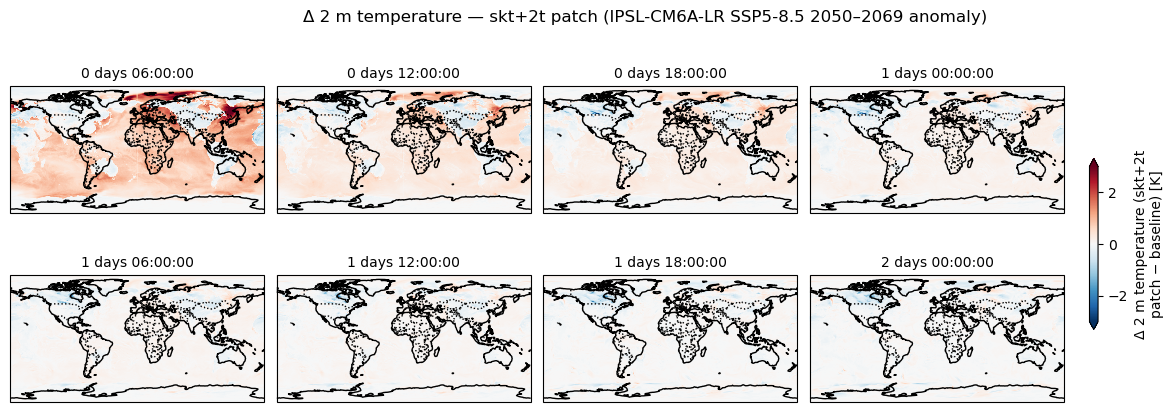

In [ ]:
anomaly_label = (
    f"{cmip6_source_id} SSP5-8.5 {cmip6_ssp_period.start}–{cmip6_ssp_period.stop} "
    "anomaly"
)
g = plot_utils.make_cartopy_facet_plot(
    diff.isel(lead_time=slice(0, 8)),
    col="lead_time",
    cmap="RdBu_r",
    vmin=-3,
    vmax=3,
    cbar_kwargs={"shrink": 0.4, "pad": 0.02},
)
# ad-hoc tuning of vspace
# g.fig.subplots_adjust(hspace=0.05)
w, h = g.fig.get_size_inches()
g.fig.set_size_inches(w, h * 0.75)
g.set_titles("{value}")
g.fig.suptitle(f"Δ 2 m temperature — skt+2t patch ({anomaly_label})", y=1.02)

It seems like the anomaly that is clarly visible at +6h is practically gone after +24h, which is consistent with the limitations of current AI-based weather models in extrapolate and reliably forecast beyond their training domain {cite}`zhang2026physics`, but this is beyond the scope of this notebook.

## Cleanup

Remove all forecast data from the bucket:

In [ ]:
import storage_utils

storage_utils.delete_prefixes(
    storage_bucket,
    baseline_outputs_prefix,
    patched_outputs_prefix,
)

deleted 3104 object(s) under s3://aifs-modal-unibe/aifs-outputs-ifs-baseline
deleted 2509 object(s) under s3://aifs-modal-unibe/aifs-outputs-ifs-warm-2t-skt-patch
done — removed 5613 objects from s3://aifs-modal-unibe/


## References

```{bibliography}
:filter: docname in docnames
```